In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import linear_model

# Splitting available dataset into training and test

In [49]:
df = pd.read_csv(r"C:\Users\musta\Downloads\carprices (1).csv")
df

,Mileage,Age(yrs),Sell Price($)
0,69000,6,18000
1,35000,3,34000
2,57000,5,26100
3,22500,2,40000
4,46000,4,31500
5,59000,5,26750
6,52000,5,32000
7,72000,6,19300
8,91000,8,12000
9,67000,6,22000


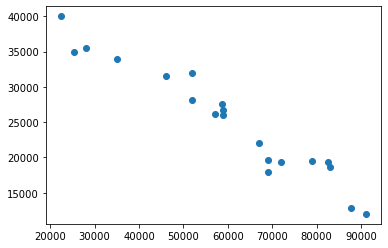

In [50]:
plt.scatter(df['Mileage'],df['Sell Price($)'])

In [51]:
x = df[['Mileage','Age(yrs)']]
y = df['Sell Price($)']

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 10)

In [54]:
x_train

,Mileage,Age(yrs)
3,22500,2
18,87600,8
13,58780,4
2,57000,5
14,82450,7
8,91000,8
17,69000,5
16,28000,2
19,52000,5
12,59000,5


In [55]:
y_train

3     40000
18    12800
13    27500
2     26100
14    19400
8     12000
17    19700
16    35500
19    28200
12    26000
11    19500
1     34000
0     18000
15    35000
4     31500
9     22000
Name: Sell Price($), dtype: int64

In [56]:
reg = linear_model.LinearRegression()
reg

LinearRegression()

In [57]:
reg.fit(x_train,y_train)

LinearRegression()

In [58]:
reg.predict(x_test)

array([20474.0745775 , 16352.07892168, 25174.14834912, 27197.42175439])

In [59]:
y_test

7     19300
10    18700
5     26750
6     32000
Name: Sell Price($), dtype: int64

In [60]:
reg.score(x_test,y_test)

0.7332339593090138

# Logistic Regression

In [61]:
df = pd.read_csv(r"C:\Users\musta\Downloads\insurance_data.csv")

In [62]:
#df

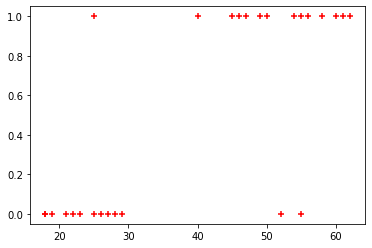

In [63]:
plt.scatter(df.age,df.bought_insurance,marker="+",color='red')

In [64]:
x_train,x_test,y_train,y_test = train_test_split(df[['age']],df.bought_insurance,test_size=0.1)

In [65]:
len(x_test)

3

In [66]:
reg.fit(x_train,y_train)

LinearRegression()

In [67]:
reg.predict(x_test)

array([0.28096096, 1.04856681, 0.95552367])

In [68]:
y_test

13    0
8     1
17    1
Name: bought_insurance, dtype: int64

In [69]:
reg.score(x_test,y_test)

0.8750860932263336

In [70]:
reg.predict([[25]])

array([0.18791782])

# HR ANALYTICS

In [71]:
hr = pd.read_csv(r"C:\Users\musta\Downloads\HR_comma_sep.csv")
pd.options.display.max_columns = None
pd.options.display.max_rows = None

#hr.head(20)

In [72]:
#print(hr.describe())
print(hr['Department'].value_counts())
print(hr['left'].value_counts())

sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: Department, dtype: int64
0    11428
1     3571
Name: left, dtype: int64


In [73]:
left = hr[hr.left==1]
retained = hr[hr.left==0]
print(left.shape,retained.shape)

(3571, 10) (11428, 10)


In [74]:
hr.groupby('left').mean()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


In [75]:
hr.groupby(['left'])['Department'].value_counts()

left  Department 
0     sales          3126
      technical      2023
      support        1674
      IT              954
      product_mng     704
      RandD           666
      marketing       655
      accounting      563
      management      539
      hr              524
1     sales          1014
      technical       697
      support         555
      IT              273
      hr              215
      accounting      204
      marketing       203
      product_mng     198
      RandD           121
      management       91
Name: Department, dtype: int64

In [76]:
hr.groupby(['left'])['salary'].value_counts()

left  salary
0     low       5144
      medium    5129
      high      1155
1     low       2172
      medium    1317
      high        82
Name: salary, dtype: int64

# Impact of employee department on retention

<AxesSubplot:xlabel='Department'>

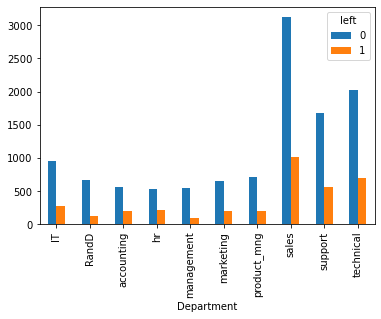

In [77]:
pd.crosstab(hr.Department,hr.left).plot(kind = 'bar')

# Impact of Salary on employee retention


<AxesSubplot:xlabel='salary'>

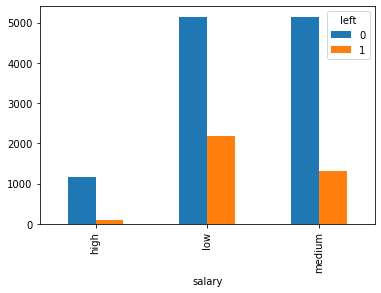

In [78]:
pd.crosstab(hr.salary,hr.left).plot(kind = 'bar')

In [79]:
subhr = pd.get_dummies(hr.salary)


In [103]:
hr_final = hr[['satisfaction_level','average_montly_hours','promotion_last_5years']]

In [104]:
subhr_merged = pd.concat([hr_final, subhr] , axis = "columns")

In [105]:
##hr_final

In [106]:
#subhr_merged

In [110]:
X = subhr_merged
X.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,high,low,medium
0,0.38,157,0,0,1,0
1,0.80,262,0,0,0,1
2,0.11,272,0,0,0,1
3,0.72,223,0,0,1,0
4,0.37,159,0,0,1,0


In [111]:
Y = hr.left
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size = 0.3)

In [114]:
#X_train

In [115]:
Y_train.describe()

count    4499.000000
mean        0.237608
std         0.425665
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: left, dtype: float64

In [116]:
model = linear_model.LinearRegression()

In [117]:
model.fit(X_train,Y_train)

LinearRegression()

In [120]:
print('X_test.shape: ', X_test.shape, 'X_train.shape: ', X_train.shape)

X_test.shape:  (10500, 6) X_train.shape:  (4499, 6)


In [124]:
predictions = model.predict(X_test)
predictions

array([0.16307543, 0.45130905, 0.20915187, ..., 0.1322774 , 0.2083851 ,
       0.09281561])

In [ ]:
model.score(X_test,Y)